In [ ]:
#Q.predict whether patient will be diabetic or not

In [1]:
#read file\\
import pandas as pd
diabetes_df = pd.read_csv("diabetes (1).xls")
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
#checking null values\\
diabetes_df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [3]:
diabetes_df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [4]:
diabetes_df["Outcome"].value_counts(normalize=True) *100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

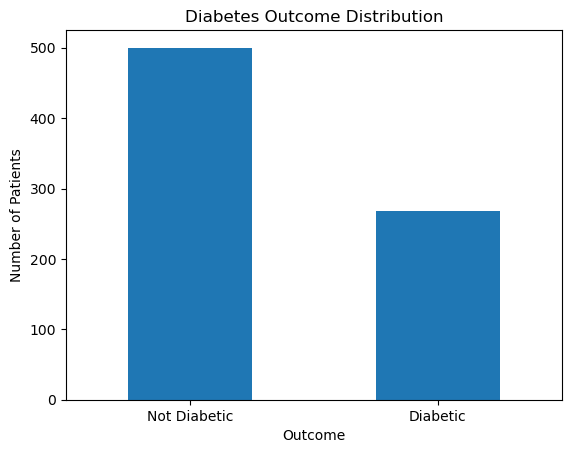

In [5]:
##EDA
#diabetic vs non diabetic\\
import matplotlib.pyplot as plt
diabetes_df["Outcome"].value_counts().plot(kind = "bar")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["Not Diabetic", "Diabetic"], rotation=0)
plt.show()

In [6]:
#Compare glucose levels
diabetes_df.groupby("Outcome")["Glucose"].mean()

Outcome
0    109.980000
1    141.257463
Name: Glucose, dtype: float64

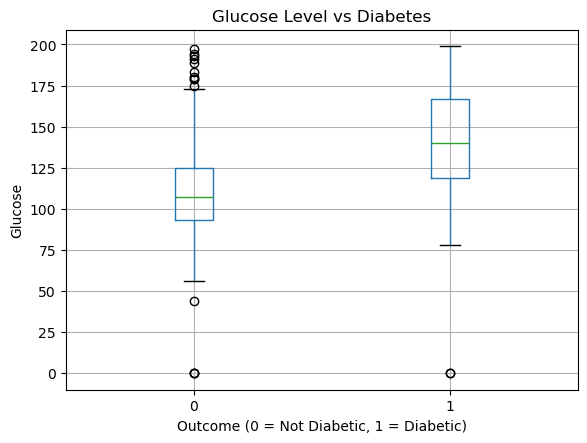

In [7]:
diabetes_df.boxplot(column="Glucose", by="Outcome")
plt.title("Glucose Level vs Diabetes")
plt.suptitle("")
plt.xlabel("Outcome (0 = Not Diabetic, 1 = Diabetic)")
plt.ylabel("Glucose")
plt.show()

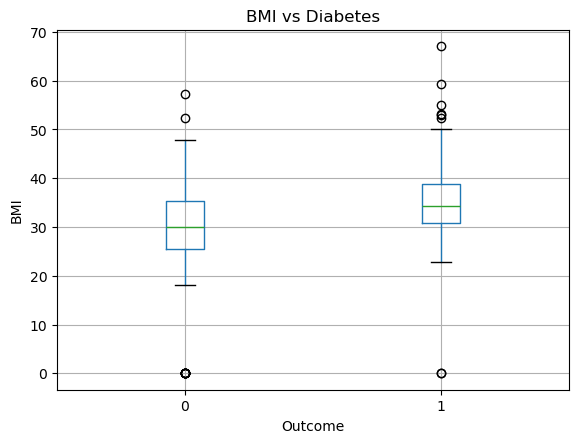

In [8]:
#BMI vs diabetes
diabetes_df.boxplot(column="BMI", by="Outcome")
plt.title("BMI vs Diabetes")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("BMI")
plt.show()

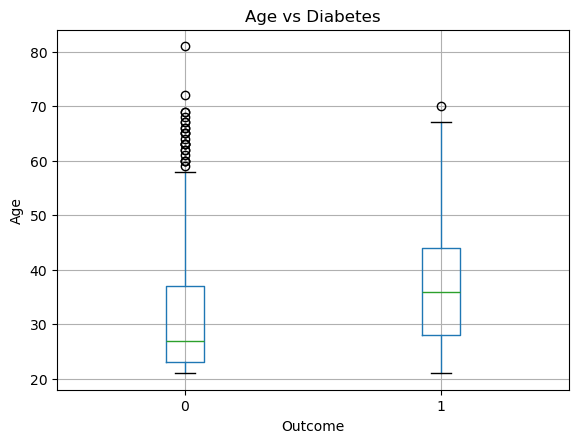

In [9]:
#Age vs diabetes
diabetes_df.boxplot(column="Age", by="Outcome")
plt.title("Age vs Diabetes")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Age")
plt.show()

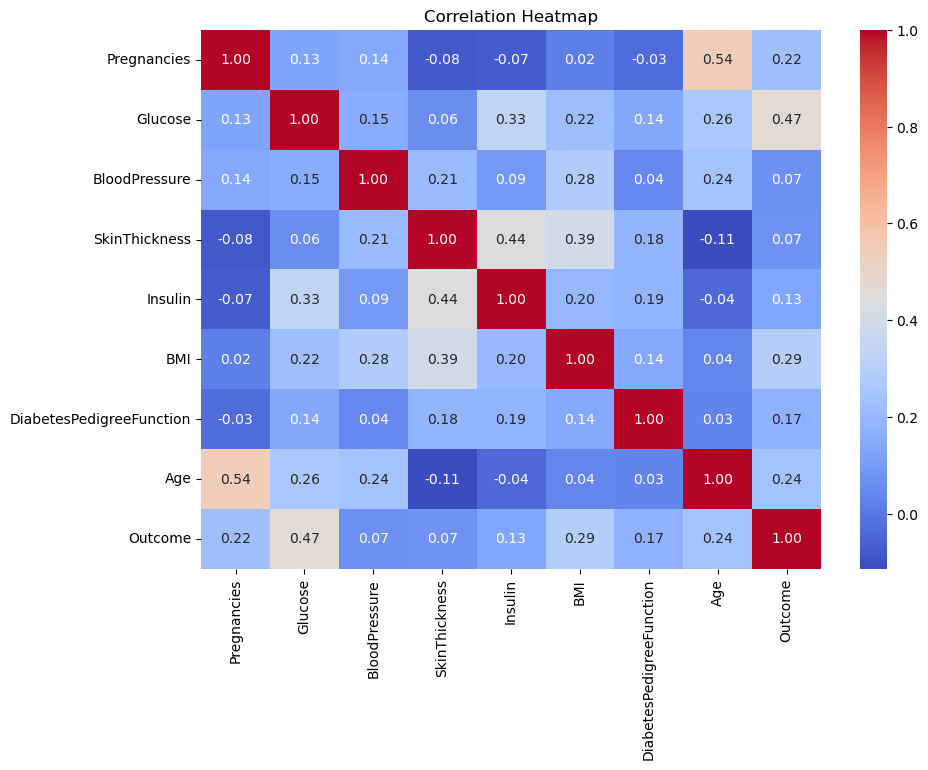

In [10]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
sns.heatmap(diabetes_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
#splitting the data into training and testing sets\\
from sklearn.model_selection import train_test_split
x = diabetes_df.drop(columns = ["Outcome"])
y = diabetes_df["Outcome"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify = y)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print(x_train)
print(x_test)

[[-0.85135507 -0.98013068 -0.40478372 ... -0.60767846  0.31079384
  -0.79216928]
 [ 0.35657564  0.16144422  0.46536842 ... -0.30213902 -0.11643851
   0.56103382]
 [-0.5493724  -0.50447447 -0.62232176 ...  0.3725939  -0.76486207
  -0.70759409]
 ...
 [-0.85135507 -0.75815778  0.03029235 ...  0.77997981 -0.78607218
  -0.28471812]
 [ 1.86648903 -0.31421198  0.03029235 ... -0.56948603 -1.01938346
   0.56103382]
 [ 0.05459296  0.73223168 -0.62232176 ... -0.31486983 -0.57700104
   0.30730824]]
[[ 0.96054099  1.20788789 -0.29601471 ... -0.58221684 -0.55579092
   0.56103382]
 [ 1.86648903 -1.67775979  1.98813468 ...  0.44897876 -0.58306107
   1.15306018]
 [-0.5493724   0.03460257  0.3565994  ...  0.499902    0.01688223
  -0.6230189 ]
 ...
 [-0.5493724  -1.23381399 -0.94862882 ... -0.44217793  3.70138246
  -0.70759409]
 [ 0.05459296  2.00064824  0.46536842 ...  0.6399409  -0.64669142
  -0.20014293]
 [-0.85135507 -1.58262854  0.46536842 ...  0.15617013 -0.16794879
  -1.04589487]]


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create model
logistic_model = LogisticRegression(random_state=42)

# Train model
logistic_model.fit(x_train, y_train)

# Predictions
y_pred_lr = logistic_model.predict(x_test)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.7142857142857143


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create Decision Tree model
decision_tree = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree.fit(x_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(x_test)

# Calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.7207792207792207


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(x_train, y_train)

# Make predictions
y_pred_rf = random_forest.predict(x_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7597402597402597


In [15]:
import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy(%)": [
        accuracy_lr*100,
        accuracy_dt*100,
        accuracy_rf*100
    ]
})

print(model_results)

                 Model  Accuracy(%)
0  Logistic Regression    71.428571
1        Decision Tree    72.077922
2        Random Forest    75.974026


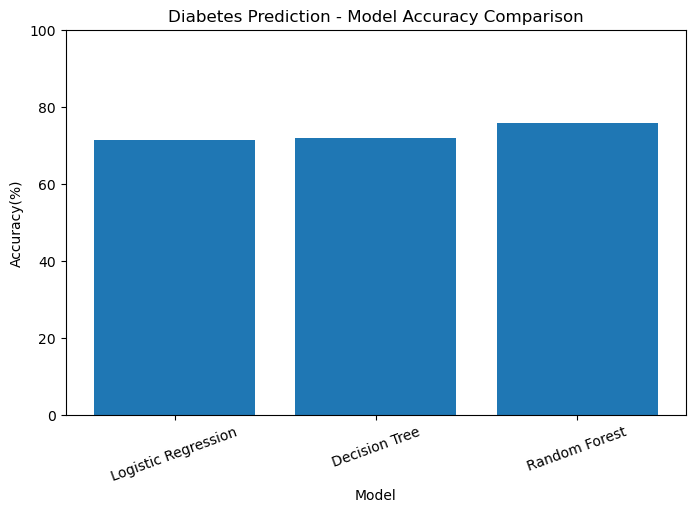

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy(%)"]
)

plt.ylabel("Accuracy(%)")
plt.xlabel("Model")
plt.title("Diabetes Prediction - Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.show()

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[85 15]
 [22 32]]


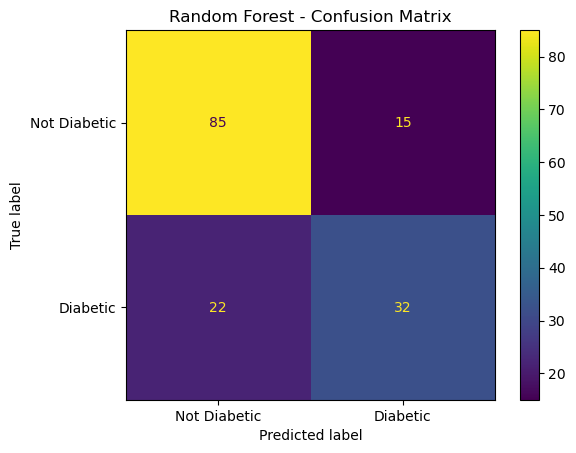

In [18]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Diabetic", "Diabetic"]
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [19]:
import pandas as pd

# New patient
new_patient = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 120,
    "BloodPressure": 70,
    "SkinThickness": 20,
    "Insulin": 79,
    "BMI": 25.0,
    "DiabetesPedigreeFunction": 0.5,
    "Age": 30
}])

# Scale using the existing scaler
new_patient_scaled = scaler.transform(new_patient)

# Predict
prediction = random_forest.predict(new_patient_scaled)

# Display result
if prediction[0] == 1:
    print("The model predicts: Diabetic")
else:
    print("The model predicts: Not Diabetic")

The model predicts: Not Diabetic


In [20]:
import joblib
joblib.dump(random_forest, "diabetes_random_forest_model.pkl")
joblib.dump(scaler, "diabetes_scaler.pkl")

['diabetes_scaler.pkl']

In [21]:
import os

print(os.path.exists("diabetes_random_forest_model.pkl"))
print(os.path.exists("diabetes_scaler.pkl"))

True
True


In [22]:
import joblib

loaded_model = joblib.load("diabetes_random_forest_model.pkl")
loaded_scaler = joblib.load("diabetes_scaler.pkl")

In [23]:
new_patient_scaled = loaded_scaler.transform(new_patient)

prediction = loaded_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("The model predicts: Diabetic")
else:
    print("The model predicts: Not Diabetic")

The model predicts: Not Diabetic


In [24]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Not Diabetic", "Diabetic"]
))

              precision    recall  f1-score   support

Not Diabetic       0.79      0.85      0.82       100
    Diabetic       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



ROC-AUC Score: 0.8147222222222222


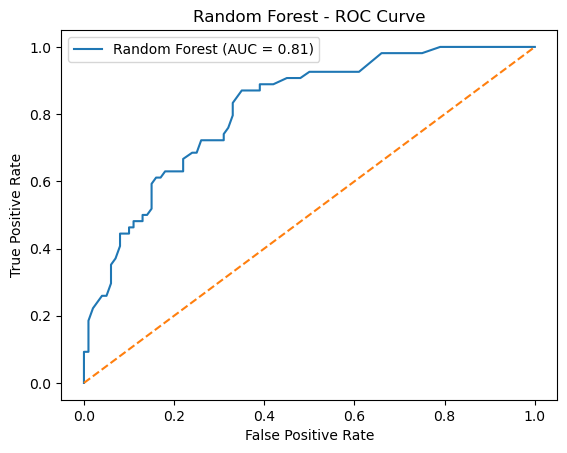

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability predictions
y_prob = random_forest.predict_proba(x_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

# Plot ROC curve
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend()
plt.show()

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": diabetes_df.drop(columns=["Outcome"]).columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                    Feature  Importance
1                   Glucose    0.276009
5                       BMI    0.159544
7                       Age    0.127248
6  DiabetesPedigreeFunction    0.126731
2             BloodPressure    0.085606
0               Pregnancies    0.084456
4                   Insulin    0.072409
3             SkinThickness    0.067997
